# EDA — Gold Price Direction & Return Forecasting

วิเคราะห์ข้อมูลราคาทองคำย้อนหลัง 10 ปี (2016–2026) ที่ดึงและประกอบ feature ไว้แล้วโดย
`ml/scripts/build_dataset.py` (Issue #2, Step 10) ครอบคลุม 6 หัวข้อตาม proposal:

1. แนวโน้มราคาทองคำ (Trend)
2. ความสัมพันธ์ (Correlation)
3. Distribution ของ return
4. ความผันผวน (Volatility)
5. การกระจายตัว (Scatter plot)
6. Outlier

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../ml/data/raw/featured_dataset.csv", parse_dates=["Date"])
print(df.shape)
df[["Date", "Close", "return_pct_t1", "direction_t1"]].head()

(2509, 54)


,Date,Close,return_pct_t1,direction_t1
0,2016-09-16,1305.800049,0.589673,up
1,2016-09-19,1313.500000,0.015223,up
2,2016-09-20,1313.699951,1.004801,up
3,2016-09-21,1326.900024,1.017409,up
4,2016-09-22,1340.400024,-0.238740,down


In [2]:
df.head()

,Date,Open,High,Low,Close,Volume,dxy_close,crude_oil_close,vix_close,treasury_10y_close,...,sp500_close_lag_2,sp500_close_lag_3,sp500_close_lag_5,sp500_close_lag_10,return_pct_t1,direction_t1,return_pct_t5,direction_t5,return_pct_t10,direction_t10
0,2016-09-16,1312.199951,1312.599976,1305.800049,1305.800049,4,96.110001,43.029999,15.37,1.701,...,NaN,NaN,NaN,NaN,0.589673,up,2.404649,up,0.574361,up
1,2016-09-19,1313.500000,1313.500000,1313.500000,1313.500000,20,95.839996,43.299999,15.53,1.696,...,NaN,NaN,NaN,NaN,0.015223,up,1.994667,up,-0.342596,down
2,2016-09-20,1313.699951,1313.699951,1313.699951,1313.699951,97,96.019997,43.439999,15.92,1.688,...,2139.159912,NaN,NaN,NaN,1.004801,up,0.928680,up,-3.608122,down
3,2016-09-21,1326.300049,1326.900024,1324.000000,1326.900024,76,95.660004,45.340000,13.30,1.668,...,2139.120117,2139.159912,NaN,NaN,1.017409,up,-0.565227,down,-4.649941,down
4,2016-09-22,1338.599976,1340.400024,1338.199951,1340.400024,23,95.449997,46.320000,12.02,1.632,...,2139.760010,2139.120117,NaN,NaN,-0.238740,down,-1.395111,down,-6.759174,down


In [3]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'dxy_close',
       'crude_oil_close', 'vix_close', 'treasury_10y_close', 'sp500_close',
       'ma_5', 'ma_20', 'ema_12', 'ema_26', 'rsi_14', 'macd', 'macd_signal',
       'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_5',
       'Close_lag_10', 'dxy_close_lag_1', 'dxy_close_lag_2', 'dxy_close_lag_3',
       'dxy_close_lag_5', 'dxy_close_lag_10', 'crude_oil_close_lag_1',
       'crude_oil_close_lag_2', 'crude_oil_close_lag_3',
       'crude_oil_close_lag_5', 'crude_oil_close_lag_10', 'vix_close_lag_1',
       'vix_close_lag_2', 'vix_close_lag_3', 'vix_close_lag_5',
       'vix_close_lag_10', 'treasury_10y_close_lag_1',
       'treasury_10y_close_lag_2', 'treasury_10y_close_lag_3',
       'treasury_10y_close_lag_5', 'treasury_10y_close_lag_10',
       'sp500_close_lag_1', 'sp500_close_lag_2', 'sp500_close_lag_3',
       'sp500_close_lag_5', 'sp500_close_lag_10', 'return_pct_t1',
       'direction_t1', 'return_pct_t5', 'd

## 1. แนวโน้มราคาทองคำ (Trend)

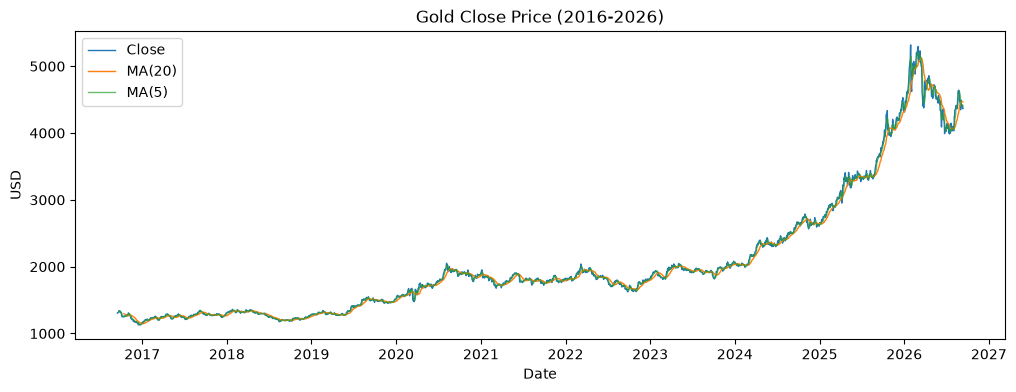

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["Date"], df["Close"], label="Close", linewidth=1)
ax.plot(df["Date"], df["ma_20"], label="MA(20)", linewidth=1)
ax.plot(df["Date"], df["ma_5"], label="MA(5)", linewidth=1, alpha=0.7)
ax.set_title("Gold Close Price (2016-2026)")
ax.set_xlabel("Date")
ax.set_ylabel("USD")
ax.legend()
plt.show()

**วิเคราะห์**: ราคาทองปรับตัวขึ้นตลอด 10 ปี โดยเฉพาะเร่งตัวแรงมากในช่วง 2-3 ปีหลัง (จาก ~1,300 ดอลลาร์ ในปี 2016 ไปแตะ 5,000+ ดอลลาร์ในช่วงปี 2026) เส้น MA(5) และ MA(20) เกาะติดราคาใกล้กันในช่วงที่ตลาดนิ่ง แต่ห่างออกจากกันชัดเจนในช่วงที่ราคาแกว่งแรง (ใช้เป็นสัญญาณ trend-following ได้) แนวโน้มขาขึ้นที่ยาวและแรงขนาดนี้เป็นสัญญาณว่าข้อมูล 10 ปีนี้ไม่ใช่ sideway market — โมเดลต้องระวังไม่ over-fit กับช่วงขาขึ้นแรงตอนท้าย


## 2. ความสัมพันธ์ (Correlation)

เทียบราคาปิดของทองกับราคาปิดของ macro indicator แต่ละตัว

In [5]:
corr_cols = ["Close", "dxy_close", "crude_oil_close", "vix_close", "treasury_10y_close", "sp500_close"]
corr = df[corr_cols].corr()
corr

,Close,dxy_close,crude_oil_close,vix_close,treasury_10y_close,sp500_close
Close,1.000000,0.216675,0.302076,0.068200,0.583457,0.924805
dxy_close,0.216675,1.000000,0.433850,0.079201,0.630579,0.334217
crude_oil_close,0.302076,0.433850,1.000000,-0.069411,0.559429,0.482606
vix_close,0.068200,0.079201,-0.069411,1.000000,-0.257618,0.006533
treasury_10y_close,0.583457,0.630579,0.559429,-0.257618,1.000000,0.659424
sp500_close,0.924805,0.334217,0.482606,0.006533,0.659424,1.000000


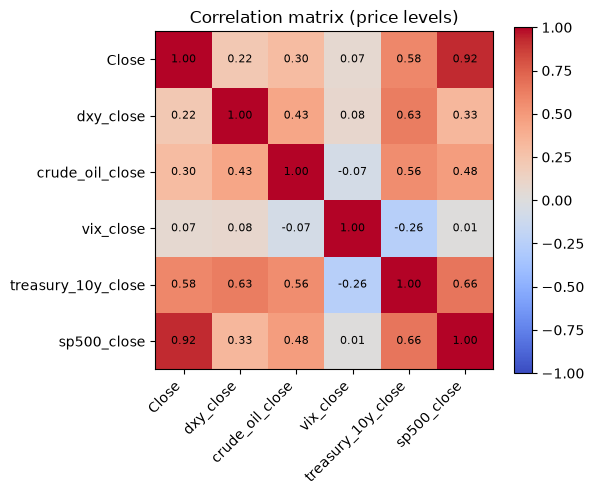

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im)
ax.set_title("Correlation matrix (price levels)")
plt.tight_layout()
plt.show()

**วิเคราะห์**: correlation ที่คำนวณจาก **ราคาระดับ (price level)** ให้ผลที่ต้องอ่านอย่าง ระมัดระวัง — ทองกับ S&P500 มี correlation สูงถึง **0.92** และทองกับพันธบัตร 10 ปี **0.58** ซึ่งขัดกับความเข้าใจทั่วไปที่ว่าทองมักสวนทางหุ้น เหตุผลคือ**ทั้งคู่แค่บังเอิญเป็นขาขึ้นยาว พร้อมกันในช่วง 10 ปีนี้** (spurious correlation จาก shared trend ไม่ใช่ความสัมพันธ์เชิงเหตุผล) ส่วนทองกับ DXY ที่ correlation ระดับราคาแค่ **0.22** (อ่อนกว่าที่คาด) แต่พอไปดู correlation ของ **daily return** ในหัวข้อ Scatter Plot (ข้อ 5) กลับได้ **-0.40** ซึ่งตรงกับทฤษฎีชัดเจนกว่ามาก — บทเรียนสำคัญ: **ควรดู correlation จาก return/การเปลี่ยนแปลง ไม่ใช่ราคาระดับ** เวลาต้องการ หาความสัมพันธ์เชิงเศรษฐศาสตร์จริง แต่ feature ที่ใช้เทรนโมเดลยังคงใช้ราคาระดับได้ เพราะ tree-based model (XGBoost/LightGBM) จับ pattern แบบไม่เชิงเส้นได้เอง ไม่ต้องพึ่ง correlation เชิงเส้น


## 3. Distribution ของ Return

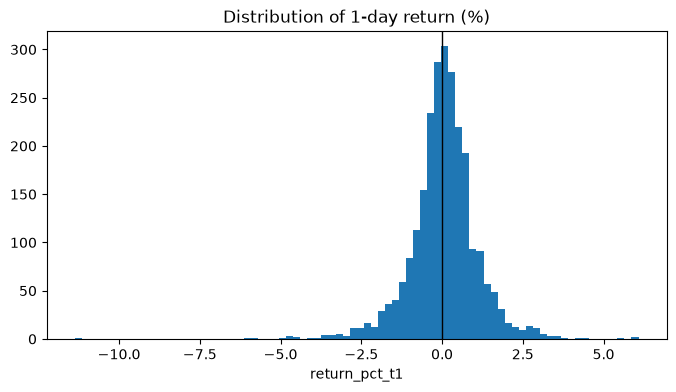

count    2508.000000
mean        0.053785
std         1.060081
min       -11.366201
25%        -0.423045
50%         0.067740
75%         0.595162
max         6.083292
Name: return_pct_t1, dtype: float64

In [7]:
returns = df["return_pct_t1"].dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(returns, bins=80)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Distribution of 1-day return (%)")
ax.set_xlabel("return_pct_t1")
plt.show()

returns.describe()

**วิเคราะห์**: distribution เป็นทรง **fat-tail** เกาะกลางแคบแต่มีหางยาวทั้ง 2 ฝั่ง (std = 1.06% แต่ min ลึกถึง -11.37% และ max ถึง +6.08% ซึ่งเกินกว่า 3 std ไปมาก) ตรงตามลักษณะทั่วไปของ financial return ที่**ไม่เป็น normal distribution** — ค่าเฉลี่ย (mean = +0.054%) เป็นบวกเล็กน้อย สอดคล้องกับที่เห็นในกราฟ Trend ว่าทองเป็นขาขึ้นระยะยาว แต่ median (+0.068%) ใกล้เคียง mean มาก แปลว่าวันปกติทั่วไปขยับเบามาก ความเสี่ยงส่วนใหญ่ กระจุกอยู่ใน**วันที่ผิดปกติไม่กี่วัน** — ตรงนี้มีนัยสำคัญต่อ Backtest: กลยุทธ์ที่ดูดีในวันปกติ อาจพังได้จากวันสุดโต่งแค่ไม่กี่วัน


## 4. ความผันผวน (Volatility)

ใช้ rolling standard deviation ของ daily return ในช่วง 20 วัน เป็นตัววัดความผันผวนที่เปลี่ยนไป
ตามเวลา

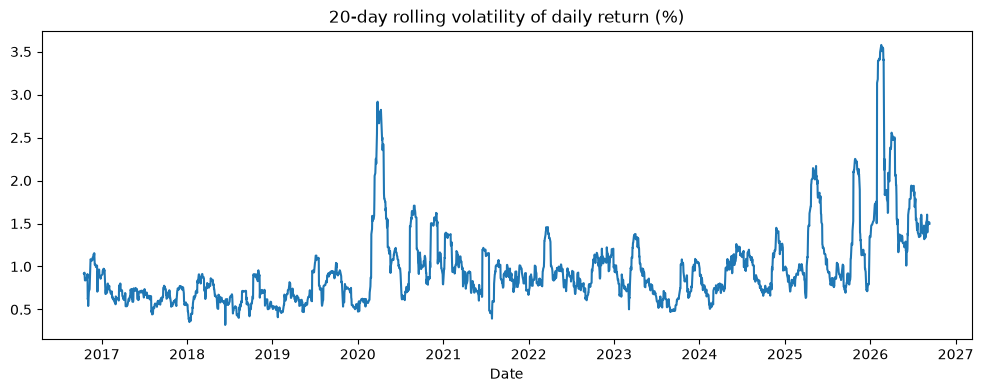

In [8]:
daily_return = df["Close"].pct_change() * 100
rolling_vol = daily_return.rolling(window=20).std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["Date"], rolling_vol)
ax.set_title("20-day rolling volatility of daily return (%)")
ax.set_xlabel("Date")
plt.show()

**วิเคราะห์**: ความผันผวนไม่คงที่ตลอดเวลา (volatility clustering) — มีช่วงที่ rolling volatility พุ่งสูงชัดเจนเป็นหย่อมๆ แทนที่จะกระจายสม่ำเสมอ ตรงกับช่วงเวลาที่ตรวจพบ outlier หนาแน่นในข้อ 6 (เช่น ต้นปี 2020 ช่วง COVID, และหลายช่วงในปี 2025-2026) — นัยสำคัญคือ **โมเดลควรมี feature ที่รู้ตัวว่าอยู่ในช่วงผันผวนสูงหรือต่ำ** (เช่น ใช้ vix_close หรือ rolling std เป็น feature เพิ่ม) เพราะ error ของโมเดลมักสูงกว่าปกติในช่วงผันผวนสูง และ position sizing ใน Backtest ควรพิจารณาลดขนาดการเทรดในช่วงที่ volatility สูงด้วย


## 5. การกระจายตัวด้วย Scatter Plot

เทียบ daily return ของทองกับ daily return ของ DXY (ค่าเงินดอลลาร์) — ตามทฤษฎี ทองกับดอลลาร์มัก
เคลื่อนไหวสวนทางกัน

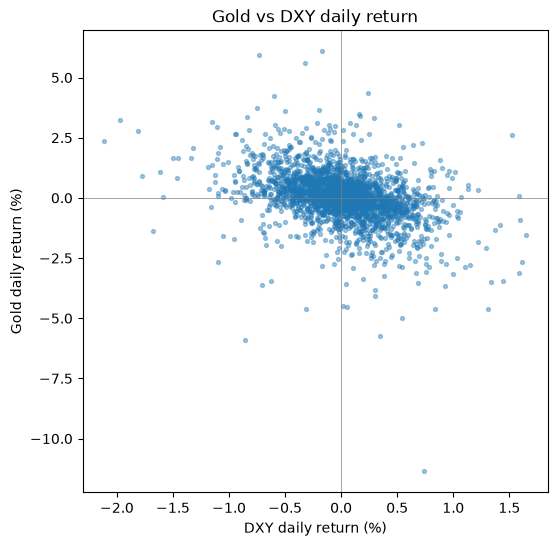

correlation: -0.396


In [9]:
gold_return = df["Close"].pct_change() * 100
dxy_return = df["dxy_close"].pct_change() * 100

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(dxy_return, gold_return, s=8, alpha=0.4)
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel("DXY daily return (%)")
ax.set_ylabel("Gold daily return (%)")
ax.set_title("Gold vs DXY daily return")
plt.show()

print("correlation:", gold_return.corr(dxy_return).round(3))

**วิเคราะห์**: scatter plot เอียงลงเล็กน้อยจากซ้ายบนไปขวาล่าง ยืนยัน correlation ติดลบ **-0.40** ระหว่าง daily return ของทองกับ DXY — ตรงตามทฤษฎีที่ว่าเงินดอลลาร์แข็งค่า (DXY ขึ้น) มักกดราคาทอง (เพราะทองซื้อขายเป็นดอลลาร์ ดอลลาร์แพงขึ้น = ทองแพงขึ้นสำหรับ สกุลเงินอื่น ความต้องการซื้อลดลง) แต่จุดกระจายตัวยังกว้างมาก (correlation แค่ -0.4 ไม่ใช่ -1) แปลว่า DXY เป็นแค่ **หนึ่งในหลายปัจจัย** ที่มีผลต่อราคาทอง ไม่ใช่ตัวกำหนดเดียว — สนับสนุน การใช้ macro indicator หลายตัวพร้อมกัน (ตามที่ proposal ออกแบบไว้) แทนที่จะพึ่ง DXY อย่างเดียว


## 6. Outlier Analysis

หาวันที่ return ผิดปกติมาก ด้วย z-score (ห่างจากค่าเฉลี่ยเกิน 3 เท่าของ standard deviation)

In [10]:
z_score = (returns - returns.mean()) / returns.std()
outliers = df.loc[returns.index][z_score.abs() > 3][["Date", "Close", "return_pct_t1"]]
print(f"outlier days (|z-score| > 3): {len(outliers)}")
outliers

outlier days (|z-score| > 3): 33


,Date,Close,return_pct_t1
11,2016-10-03,1309.000000,-3.262028
38,2016-11-10,1265.500000,-3.500597
689,2019-06-19,1344.599976,3.592150
863,2020-02-27,1640.000000,-4.628050
872,2020-03-11,1641.400024,-3.174118
873,2020-03-12,1589.300049,-4.630976
879,2020-03-20,1484.000000,5.592992
880,2020-03-23,1567.000000,5.947668
892,2020-04-08,1665.400024,4.251226
977,2020-08-10,2024.400024,-4.534679


**วิเคราะห์**: พบวันที่ return ผิดปกติ (|z-score| > 3) ทั้งหมด **33 วัน** จาก 2,508 วัน (ประมาณ 1.3% ของข้อมูล) ซึ่งมากกว่าที่ normal distribution ควรจะมี (ทฤษฎีคาดว่า < 0.3%) ยืนยันลักษณะ fat-tail อีกครั้ง — สังเกตว่า**วันเหล่านี้ไม่ได้กระจายสุ่ม แต่กระจุกตัวเป็นช่วงๆ** ตรงกับเหตุการณ์จริง: ต้นปี 2020 (วิกฤต COVID, หลายวันติดกัน), และช่วงปี 2025-2026 ที่มี วันผันผวนถี่ผิดปกติ โดยวันที่รุนแรงที่สุดคือ **2026-01-29 ที่ return -11.37% วันเดียว** (รุนแรงกว่าค่าเฉลี่ย ±10 เท่า) — ข้อควรระวังสำหรับ Backtest: outlier ระดับนี้ทำให้ metric อย่าง Sharpe ratio อ่อนไหวต่อวันเดียวมาก ควรดู max drawdown ควบคู่ไปด้วย ไม่ใช่ดู Sharpe อย่างเดียว
